In [225]:
import numpy as np
import math
import sympy as sp # для символьных вычислений
import matplotlib.pyplot as plt #  для построения графиков 
from tabulate import tabulate


# Функция для вычисления значения функции function от t
def compute_function(function_str,t): 
    function_str = function_str.replace("^", "**")  # Исправляем возведение в степень
    t_sym = sp.symbols('t') # символьная переменная t
    expr = sp.sympify(function_str)  # Преобразуем строку в математическое выражение
    return float(expr.subs(t_sym, t)) # заменяет символьную переменную t на число

#Класс реализующий НС
class network:
    # создаётся массив весов размером size+1 (доп. вес для смещения)
    def __init__(self, p): 
        self.weights=np.zeros(p) # веса (p + bias)
        # self.weights=np.zeros(p) # веса (p + bias)

    # Функция активации (линейная)
    def activation_function(self, net):
        return net
     
    # Функция предсказания 
    def predict(self, inputs):
        return self.activation_function(np.dot(inputs,self.weights)) 

    # Функция обучения нейросети с использованием дельта-правила Видроу-Хоффа
    def train(self, inputs, outputs, epoch_max):        
        eta = 1  # норма обучения
        epoch = 1  # номер эпохи
        # E = 1000   # начальное значение ошибки (чтобы войти в цикл)
        table = []  # список для строк таблицы)
        
        while epoch <= epoch_max:
            predict_outputs = []   # Список для хранения предсказанных выходов эпохи
            sq_sum_delta = 0       # Сумма квадратов ошибок для эпохи
            # Сохраняем веса перед началом эпохи для логирования
            weights_before_epoch = np.copy(self.weights)
            
            # Проходим по каждому обучающему примеру
            for i in range(len(inputs)):
                # Добавляем bias (единица) в начало входного вектора
                # single_input = np.insert(inputs[i], 0, 1)  
                single_input = inputs[i]
                # Вычисляем комбинированный вход (net)
                net = np.dot(single_input, self.weights)
                # Прогнозируемый выход: применяем функцию активации напрямую к net
                single_predict_output = self.activation_function(net)
                predict_outputs.append(single_predict_output)
                # Вычисляем ошибку (дельту)
                delta = outputs[i] - single_predict_output
                # Аккумулируем сумму квадратов ошибок
                sq_sum_delta += delta ** 2  
                # Коррекция весов: eta * delta * вход (с bias)
                correction = eta * delta * single_input      
                self.weights += correction  # Обновляем веса
            # Вычисляем корень из суммы квадратов ошибок для эпохи
            E = np.sqrt(sq_sum_delta)
            # добавляем строку для таблицы
            table.append([epoch, str(np.round(weights_before_epoch, 3)), 
                     np.array(predict_outputs), f"{E:.3f}"])   
            epoch += 1
        # вывод таблицы в консоль с использованием табулятора
        headers = ["Epoch", "Weights", "Predicted Out", "Error"]
        print(tabulate(table, headers=headers, tablefmt="fancy_grid"))
        return self.weights

    def check_network_with_weights(self,inputs,outputs):
            sq_sum_delta = 0 
            predict_outputs = []
            for i in range(len(outputs)):
                # Добавляем bias (единица) в начало входного вектора
                # single_input = np.insert(inputs, 0, 1) 
                single_input = inputs
                # Вычисляем комбинированный вход (net)
                net = np.dot(single_input, self.weights)
                # Прогнозируемый выход: применяем функцию активации напрямую к net
                single_predict_output = self.activation_function(net)
                inputs = np.concatenate((inputs[1:], [single_predict_output]))
                predict_outputs.append(single_predict_output)
                # Вычисляем ошибку (дельту)
                delta = outputs[i] - single_predict_output
                # Аккумулируем сумму квадратов ошибок
                sq_sum_delta += delta ** 2
                
            E_check = np.sqrt(sq_sum_delta)
            return E_check, predict_outputs

# Функция для создания обучающих данных методом "скользящего окна"
def create_training_data(X_values, p):
    inputs = [] # список для входных данных
    outputs= [] # списко для ожидаемых значений
    for i in range(len(X_values) - p): # проходим по ряду, оставляя место для окна
        inputs.append(X_values[i:i+p]) # берем p значений, начиная с индекса i, как входные данные
        outputs.append(X_values[i+p]) # значение после окна - ожидаемый выход
    return inputs, outputs 

# Функция для построения графика функции
def plot_function(t_values, X_values, t_predict=None, predicted_values=None, p = 6, N = 20, M=None, E=None):
        plt.figure(figsize=(8, 5))
        
        if predicted_values is not None:
            plt.plot(np.concatenate((t_values, t_predict)), X_values, 'k-', label="X(t)")
            plt.scatter(t_values[-p:], X_values[:N][-p:], color='r', marker='o', label="Прогноз")
            plt.scatter(t_predict, predicted_values, color='b', marker='o', label="Ожидание")
        else:
            plt.plot(t_values, X_values[:N], 'k-', label="X(t)")
            plt.scatter(t_values, X_values[:N], color='r', marker='o', label="x")

        legend_text = f"Эпохи M: {M}, Окно p: {p}, Ошибка E: {E:.3f}" if M is not None and E is not None else ""
        plt.legend(title=legend_text)

        plt.xlabel("t")
        plt.ylabel("X(t)")
        plt.grid(True)
        plt.title("График функции X(t)")
        plt.show()

╒═════════╤═════════════════════════════════════════════╤════════════════════════════════════════════════════════════════════════╤═════════╕
│   Epoch │ Weights                                     │ Predicted Out                                                          │   Error │
╞═════════╪═════════════════════════════════════════════╪════════════════════════════════════════════════════════════════════════╪═════════╡
│       1 │ [0. 0. 0. 0. 0. 0.]                         │ [ 0.    -1.773  2.111 -3.716  2.749 -1.539  0.001 -0.067 -0.05  -0.031 │   5.536 │
│         │                                             │  -0.018 -0.009 -0.005 -0.003]                                          │         │
├─────────┼─────────────────────────────────────────────┼────────────────────────────────────────────────────────────────────────┼─────────┤
│       2 │ [0.018 0.027 0.035 0.042 0.047 0.05 ]       │ [-0.163 -1.373  1.353 -2.679  1.839 -1.126 -0.038 -0.073 -0.051 -0.031 │   3.852 │
│         │  

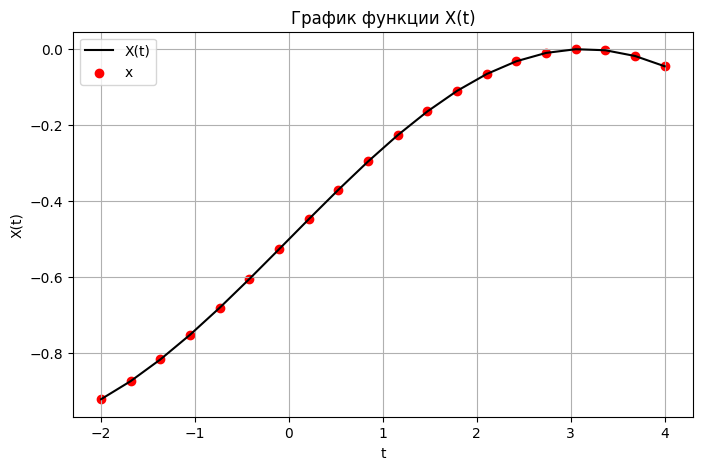

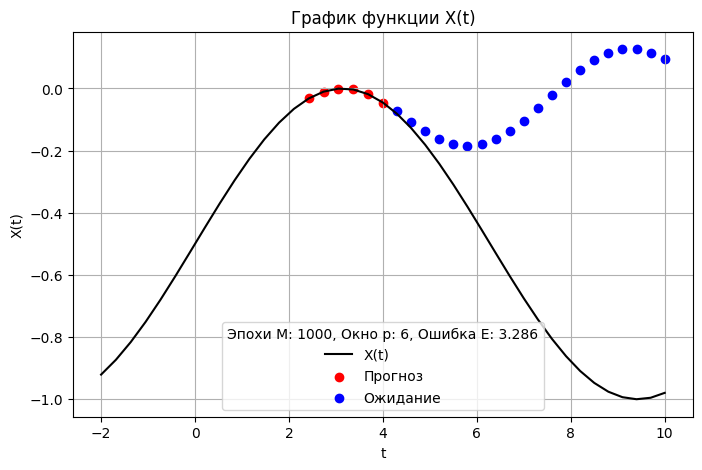

In [226]:
# Ввод исходных данных
# a, b = 4.5, 5
a, b = -2, 4
N = 20
p = 6
# x_t = "sin(2*sqrt(exp(t)))"
x_t = "0.5*sin(0.5*t) - 0.5"

# Создание значений
t_values =  np.linspace(a, b, N) # генерация значений t на интервале [a, b]
t_predict = np.linspace(b, 2*b - a, N + 1)[1:]
t_all = np.concatenate((t_values, t_predict))
X_values = np.array([compute_function(x_t,t) for t in t_all]) 
# значения функции для обучения
X_values_train = X_values[:N] 

# Исследование влияния p (размера окна)
# window_sizes = [4] 
# learning_rates = [0.01, 0.02, 0.05, 0.1]
# epochs_list = [1000, 5000, 10000, 20000]
epoch = 1000
eta = 1
# создаем обучающие данные
train_inputs, train_outputs = create_training_data(X_values_train,p)

# создаем сеть
ntw = network(p)
# обучаем сеть
weights = ntw.train(train_inputs,train_outputs, epoch) # обучаем нейронную сеть на всех данных
check_inputs = X_values_train[-p:]
check_outputs = X_values[N:]
E_check, predicted_out = ntw.check_network_with_weights(check_inputs, check_outputs)
print(f"Error:{E_check}")

plot_function(t_values, X_values, N)
plot_function(t_values, X_values, t_predict, predicted_out, p, N, epoch, E_check)

#Вывод результатов

# # График зависимости ошибки от параметров
# plt.figure(figsize=(8, 5))
# for eta in learning_rates:
#     plt.plot([e[0] for e in errors if e[1] == eta], [e[3] for e in errors if e[1] == eta], label=f"eta={eta}")
# plt.xlabel("Размер окна p")
# plt.ylabel("Среднеквадратичная ошибка")
# plt.title("Зависимость ошибки от размера окна и нормы обучения")
# plt.legend()
# plt.grid(True)
# plt.show()

# plt.figure(figsize=(8, 5))
# for epochs in epochs_list:
#     plt.plot([e[0] for e in errors if e[2] == epochs], [e[3] for e in errors if e[2] == epochs], label=f"epochs={epochs}")
# plt.xlabel("Размер окна p")
# plt.ylabel("Среднеквадратичная ошибка")
# plt.title("Зависимость ошибки от размера окна и числа эпох")
# plt.legend()
# plt.grid(True)
# plt.show()
